# CLASIFICADOR DE SPAM USANDO WORD2VEC

# 1 - instalamos librerias

In [1]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [2]:
df = pd.read_csv('/content/mail_data.csv')
df

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


# EDA

In [4]:
df.dtypes

,0
Category,object
Message,object


In [3]:
df.isnull().sum()

,0
Category,0
Message,0


# LIMPIEZA DE TEXTO SIMPLE

In [5]:
def clean_text(s: str) -> str:
    s = s.lower()
    s = re.sub(r"http\S+|www\S+", " url ", s)
    s = re.sub(r"\d+", " num ", s)
    s = re.sub(r"[^a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

In [6]:
df["text"] = df["Message"].astype(str).apply(clean_text)

In [7]:
df

,Category,Message,text
0,ham,"Go until jurong point, crazy.. Available only ...",go until jurong point crazy available only in ...
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry in num a wkly comp to win fa cup fi...
3,ham,U dun say so early hor... U c already then say...,u dun say so early hor u c already then say
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah i don t think he goes to usf he lives arou...
...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,this is the num nd time we have tried num cont...
5568,ham,Will ü b going to esplanade fr home?,will b going to esplanade fr home
5569,ham,"Pity, * was in mood for that. So...any other s...",pity was in mood for that so any other suggest...
5570,ham,The guy did some bitching but I acted like i'd...,the guy did some bitching but i acted like i d...


In [8]:
# === Labels: spam=1, ham=0 ===
le = LabelEncoder()
y = le.fit_transform(df["Category"])  # ham->0, spam->1
X_text = df["text"].tolist()

In [9]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", len(X_train_text), "Test:", len(X_test_text))
print("Clase spam en train:", y_train.mean().round(3), "test:", y_test.mean().round(3))

Train: 4457 Test: 1115
Clase spam en train: 0.134 test: 0.134


# ENTRENAMIENTO CON WORD2VEC

In [10]:
!pip -q install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.9 MB/s eta 0:00:00


In [11]:
from gensim.models import Word2Vec

In [12]:
train_tokens = [t.split() for t in X_train_text]
test_tokens  = [t.split() for t in X_test_text]

w2v = Word2Vec(
    sentences=train_tokens,
    vector_size=100,
    window=4,
    min_count=1,
    workers=4,
    sg=1,        # 1 = skip-gram (suele ir bien en datasets pequeños)
    epochs=30
)

print("Word2Vec listo. Vocab size:", len(w2v.wv))

Word2Vec listo. Vocab size: 6811


# Vectorizar cada mensaje

In [13]:
def sent_vec(tokens, model):
    vecs = [model.wv[w] for w in tokens if w in model.wv]
    if len(vecs) == 0:
        return np.zeros(model.vector_size)
    return np.mean(vecs, axis=0)

X_train_vec = np.vstack([sent_vec(t, w2v) for t in train_tokens])
X_test_vec  = np.vstack([sent_vec(t, w2v) for t in test_tokens])

X_train_vec.shape, X_test_vec.shape

((4457, 100), (1115, 100))

# ENTRENAMIENTO

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

clf_w2v = LogisticRegression(max_iter=2000)
clf_w2v.fit(X_train_vec, y_train)

y_pred = clf_w2v.predict(X_test_vec)

print(classification_report(y_test, y_pred, target_names=le.classes_))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.99      1.00      0.99       966
        spam       0.99      0.91      0.95       149

    accuracy                           0.99      1115
   macro avg       0.99      0.96      0.97      1115
weighted avg       0.99      0.99      0.99      1115

Confusion matrix:
 [[964   2]
 [ 13 136]]


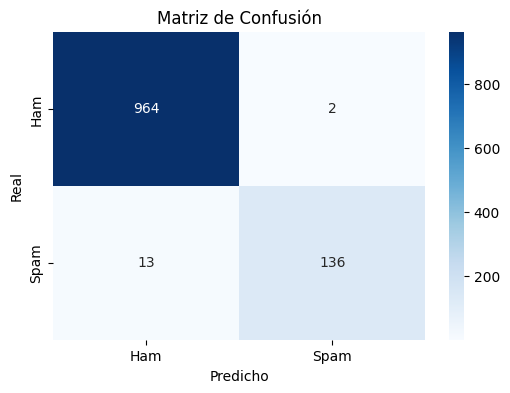

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

# PROBAMOS PREDICCIONES

In [16]:
def predict_spam_w2v(msg: str):
    msg = clean_text(msg)
    tokens = msg.split()
    v = sent_vec(tokens, w2v).reshape(1, -1)
    p = clf_w2v.predict_proba(v)[0][1]
    return ("spam" if p >= 0.5 else "ham"), float(p)

print(predict_spam_w2v("Congratulations! You've won a free ticket. Call now!"))
print(predict_spam_w2v("Hey, are we meeting today at 6?"))

('spam', 0.8579560543023131)
('ham', 0.001078814837693126)
